This model will combine the best performing carbohydrate estimation model (Model 3 V3 DINOv2) and the currently only mass estimation model (Model 18 DINOv3). These will be frozen at first for stage 1 but for stage 2 a small part of them will be unfrozen to be trained on. (similar architecture as all previous models).

CPU LOAD IN AT FIRST

In [ ]:
!pip install -q pandas numpy

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

Configuration

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_split_metadata.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

Loading metadata

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())
print("Total rows:", len(df))

           dish_id  total_mass  total_carb split source_cafe
0  dish_1556575327       152.0      10.618  test       cafe1
1  dish_1557861216         1.0       0.000  test       cafe1
2  dish_1557862345        63.0       0.000  test       cafe1
3  dish_1557862696        77.0       3.850  test       cafe1
4  dish_1557862738       118.0       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total rows: 3262


Loading RGB paths

In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


Checking for invalid images

In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print("Total remaining:", len(df))

Empty RGB files: 0

Remaining samples after filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


Splitting the dataset

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Saving split csv for GPU model training

In [ ]:
train_csv = PREP_DIR / "train_model_19.csv"
val_csv   = PREP_DIR / "val_model_19.csv"
test_csv  = PREP_DIR / "test_model_19.csv"
full_csv  = PREP_DIR / "full_filtered_model_19.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/prep_files/train_model_19.csv
/content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/prep_files/val_model_19.csv
/content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/prep_files/test_model_19.csv
/content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/prep_files/full_filtered_model_19.csv


SWITCH TO GPU FOR MODEL TRAINING

In [ ]:
!pip install -q keras-hub huggingface_hub

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

Configuration

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 2e-4
STAGE2_LR = 5e-6

CARB_BACKBONE_PRESET = "dinov2_large"
MASS_BACKBONE_PRESET = "dinov3_vit_base_lvd1689m"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_model_19.csv"
val_csv   = PREP_DIR / "val_model_19.csv"
test_csv  = PREP_DIR / "test_model_19.csv"

MODEL3_WEIGHTS = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage2.weights.h5")
MODEL18_WEIGHTS = Path("/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage2.weights.h5")

Loading dataset back in

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

display(train_df.head())

Train: 2421
Val:   334
Test:  507


,dish_id,total_mass,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,36.0,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,23.0,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,62.0,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,64.0,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,28.0,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:   ", batch_labels.shape)

RGB batch shape: (16, 224, 224, 3)
Labels shape:    (16,)


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

Building carb branch

In [ ]:
def build_model3_carb_branch():
    rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        CARB_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        CARB_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization()(x)
        x = layers.GlobalAveragePooling1D(name="token_pool")(x)
    else:
        x = layers.LayerNormalization()(x)
        x = layers.Flatten()(x)

    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.3)(x)
    feat = layers.Dense(64, activation="relu", name="dense_64")(x)
    output = layers.Dense(1, activation="linear", name="carb_output")(feat)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="rgb_only_dino_vit_regressor"
    )

    return model

Mass estimation branch

In [ ]:
def build_model18_mass_branch():
    rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        MASS_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        MASS_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization()(x)
        x = layers.GlobalAveragePooling1D(name="token_pool")(x)
    else:
        x = layers.LayerNormalization()(x)
        x = layers.Flatten()(x)

    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.3)(x)
    feat = layers.Dense(64, activation="relu", name="dense_64")(x)
    output = layers.Dense(1, activation="linear", name="mass_output")(feat)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="rgb_only_dinov3_mass_regressor"
    )

    return model

Instantiate and load pretrained weights

In [ ]:
carb_branch_model = build_model3_carb_branch()
mass_branch_model = build_model18_mass_branch()

carb_branch_model.load_weights(str(MODEL3_WEIGHTS))
mass_branch_model.load_weights(str(MODEL18_WEIGHTS))

print("Loaded Model 3 v3 carb branch weights.")
print("Loaded Model 18 mass branch weights.")

100%|██████████| 782/782 [00:00<00:00, 1.78MB/s]


100%|██████████| 977/977 [00:00<00:00, 2.30MB/s]


100%|██████████| 1.14G/1.14G [00:20<00:00, 59.5MB/s]


100%|██████████| 1.13k/1.13k [00:00<00:00, 2.59MB/s]


100%|██████████| 978/978 [00:00<00:00, 2.01MB/s]


100%|██████████| 327M/327M [00:05<00:00, 65.4MB/s]


Loaded Model 3 v3 carb branch weights.
Loaded Model 18 mass branch weights.


Creating feature extractors from the pretrained branches

In [ ]:
carb_feature_model = keras.Model(
    inputs=carb_branch_model.input,
    outputs=[
        carb_branch_model.get_layer("dense_64").output,
        carb_branch_model.output
    ],
    name="carb_feature_model"
)

mass_feature_model = keras.Model(
    inputs=mass_branch_model.input,
    outputs=[
        mass_branch_model.get_layer("dense_64").output,
        mass_branch_model.output
    ],
    name="mass_feature_model"
)

Freezing both branches for stage 1 training

In [ ]:
carb_feature_model.trainable = False
mass_feature_model.trainable = False

print("Carb feature model trainable:", carb_feature_model.trainable)
print("Mass feature model trainable:", mass_feature_model.trainable)

Carb feature model trainable: False
Mass feature model trainable: False


Building full model with attention fusion head

In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

carb_feat, carb_pred = carb_feature_model({"rgb_input": rgb_input}, training=False)
mass_feat, mass_pred = mass_feature_model({"rgb_input": rgb_input}, training=False)

# ---------------------------------------------------------
# Project each branch feature into the same shared space
# ---------------------------------------------------------
carb_proj = layers.Dense(128, activation="relu", name="carb_proj")(carb_feat)
mass_proj = layers.Dense(128, activation="relu", name="mass_proj")(mass_feat)

# ---------------------------------------------------------
# Stack the two branches as tokens: [batch, 2, 128]
# ---------------------------------------------------------
branch_tokens = layers.Lambda(
    lambda x: tf.stack(x, axis=1),
    name="branch_token_stack"
)([carb_proj, mass_proj])

# ---------------------------------------------------------
# Multi-head self-attention across the two branch tokens
# ---------------------------------------------------------
attn_output = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.1,
    name="branch_attention"
)(branch_tokens, branch_tokens)

attn_output = layers.Add(name="attn_residual")([branch_tokens, attn_output])
attn_output = layers.LayerNormalization(name="attn_norm")(attn_output)

# ---------------------------------------------------------
# Feed-forward block
# ---------------------------------------------------------
ffn = layers.Dense(128, activation="relu", name="attn_ffn_1")(attn_output)
ffn = layers.Dropout(0.2, name="attn_ffn_dropout")(ffn)
ffn = layers.Dense(128, activation="linear", name="attn_ffn_2")(ffn)

attn_output = layers.Add(name="ffn_residual")([attn_output, ffn])
attn_output = layers.LayerNormalization(name="ffn_norm")(attn_output)

# ---------------------------------------------------------
# Pool across the two branch tokens
# ---------------------------------------------------------
attn_pooled = layers.GlobalAveragePooling1D(name="attn_pool")(attn_output)

# ---------------------------------------------------------
# Add scalar predictions from both pretrained branches
# ---------------------------------------------------------
fusion = layers.Concatenate(name="fusion_concat")(
    [attn_pooled, carb_pred, mass_pred]
)

fusion = layers.Dense(128, activation="relu", name="fusion_dense_128")(fusion)
fusion = layers.Dropout(0.3, name="fusion_dropout_1")(fusion)
fusion = layers.Dense(64, activation="relu", name="fusion_dense_64")(fusion)
fusion = layers.Dropout(0.2, name="fusion_dropout_2")(fusion)

carb_output = layers.Dense(1, activation="linear", name="carb_output")(fusion)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=carb_output,
    name="model_19_pretrained_branch_attention_fusion"
)

model.summary()

Model: "model_19_pretrained_branch_attention_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_feature_model  │ [(None, 64),      │ 304,912,7… │ rgb_input[0][0]   │
│ (Functional)        │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_feature_model  │ [(None, 64),      │ 85,875,329 │ rgb_input[0][0]   │
│ (Functional)        │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_proj (Dense)   │ (None, 128)       │      8,320 │ carb_feature_mod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_proj (Dense)   │ (None, 128)       │      8,320 │ mass_feature_mod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_token_stack  │ (None, 2, 128)    │          0 │ carb_proj[0][0],  │
│ (Lambda)            │                   │            │ mass_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_attention    │ (None, 2, 128)    │     66,048 │ branch_token_sta… │
│ (MultiHeadAttentio… │                   │            │ branch_token_sta… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_residual (Add) │ (None, 2, 128)    │          0 │ branch_token_sta… │
│                     │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm           │ (None, 2, 128)    │        256 │ attn_residual[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_ffn_1 (Dense)  │ (None, 2, 128)    │     16,512 │ attn_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_ffn_dropout    │ (None, 2, 128)    │          0 │ attn_ffn_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_ffn_2 (Dense)  │ (None, 2, 128)    │     16,512 │ attn_ffn_dropout… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_residual (Add)  │ (None, 2, 128)    │          0 │ attn_norm[0][0],  │
│                     │                   │            │ attn_ffn_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_norm            │ (None, 2, 128)    │        256 │ ffn_residual[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_pool           │ (None, 128)       │          0 │ ffn_norm[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 130)       │          0 │ attn_pool[0][0],  │
│ (Concatenate)       │                   │            │ carb_feature_mod… │
│                     │                   │            │ mass_feature_mod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_128    │ (None, 128)       │     16,768 │ fusion_concat[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_1    │ (None, 128)       │          0 │ fusion_dense_128

 Total params: 390,929,411 (1.46 GB)

 Trainable params: 141,313 (552.00 KB)

 Non-trainable params: 390,788,098 (1.46 GB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - loss: 982.6962 - mae: 16.0041 - mse: 982.6962
Epoch 1: val_loss improved from None to 121.83229, saving model to /content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 179s 945ms/step - loss: 583.9975 - mae: 12.4549 - mse: 583.9975 - val_loss: 121.8323 - val_mae: 7.7985 - val_mse: 121.8323 - learning_rate: 2.0000e-04
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 365.3814 - mae: 9.1648 - mse: 365.3814
Epoch 2: val_loss improved from 121.83229 to 69.45571, saving model to /content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/best_model_stage1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fus

Evaluating stage 1 on test set

In [ ]:
model.load_weights(str(stage1_best_path))

stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 750ms/step - loss: 59.4450 - mae: 4.8806 - mse: 59.4450
Stage 1 test results:
loss: 59.4450
mae: 4.8806
mse: 59.4450


Stage 2 (unfreezing 15% of the backbone to train on it once again)

In [ ]:
def unfreeze_last_fraction_recursive(model_or_layer, fraction=0.15):
    all_layers = []

    for layer in model_or_layer._flatten_layers(include_self=False, recursive=True):
        all_layers.append(layer)

    weight_layers = []
    for layer in all_layers:
        if len(layer.weights) > 0:
            weight_layers.append(layer)

    n = len(weight_layers)
    unfreeze_from = int(n * (1.0 - fraction))

    for i, layer in enumerate(weight_layers):
        layer.trainable = (i >= unfreeze_from)

    print(f"Total weighted layers: {n}")
    print(f"Unfreeze from index:   {unfreeze_from}")
    print(f"Trainable layers:      {sum(int(l.trainable) for l in weight_layers)}")

In [ ]:
carb_feature_model.trainable = True
mass_feature_model.trainable = True

unfreeze_last_fraction_recursive(carb_feature_model, fraction=0.15)
unfreeze_last_fraction_recursive(mass_feature_model, fraction=0.15)

print("Stage 2 fine-tuning enabled.")

Total weighted layers: 346
Unfreeze from index:   294
Trainable layers:      52
Total weighted layers: 166
Unfreeze from index:   141
Trainable layers:      25
Stage 2 fine-tuning enabled.


Stage 2 training

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['dinov2_backbone_embeddings/mask_token', 'dinov3_backbone_embeddings/mask_token'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 89.2155 - mae: 5.0489 - mse: 89.2155
Epoch 1: val_loss improved from None to 61.17388, saving model to /content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_19_DINOv2_Carb_plus_DINOv3_Mass_Fusion/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - loss: 132.4159 - mae: 4.8836 - mse: 132.4159 - val_loss: 61.1739 - val_mae: 4.9371 - val_mse: 61.1739 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 106.4172 - mae: 4.9781 - mse: 106.4172
Epoch 2: val_loss did not improve from 61.17388
152/152 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - loss: 153.3042 - mae: 4.8890 - mse: 153.3042 - val_loss: 63.0772 - val_mae: 5.1191 - val_mse: 63.0772 - learning_rate: 5.0000e-06
Epoch 3/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 110.8391 - mae: 4.8861 - mse: 110

KeyboardInterrupt: 

Evaluating stage 2 on test set

In [ ]:
model.load_weights(str(stage2_best_path))

stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 393ms/step - loss: 68.8197 - mae: 5.2223 - mse: 68.8197
Stage 2 test results:
loss: 68.8197
mae: 5.2223
mse: 68.8197


Plotting training and validation curves

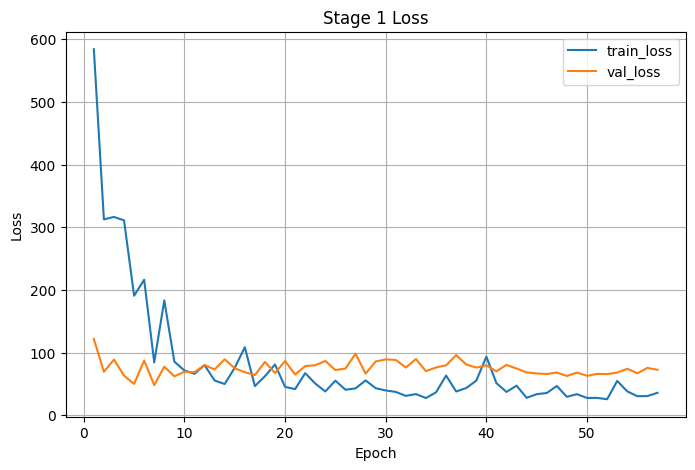

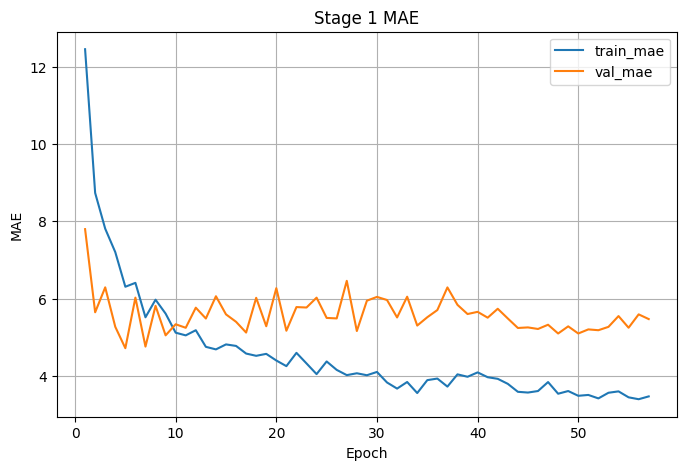

NameError: name 'history_stage2' is not defined

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Saving test prediction

In [ ]:
model.load_weights(str(stage2_best_path))

test_eval_df = test_df.copy().reset_index(drop=True)

preds = model.predict(test_dataset, verbose=1).reshape(-1)

test_eval_df["prediction"] = preds
test_eval_df["abs_error"] = np.abs(test_eval_df["total_carb"] - test_eval_df["prediction"])
test_eval_df["signed_error"] = test_eval_df["prediction"] - test_eval_df["total_carb"]

pred_csv = OUTPUT_DIR / "test_predictions_stage2.csv"
test_eval_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
display(test_eval_df.head())

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


Top 10 best and worst dishes

In [ ]:
best_10 = test_eval_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_eval_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

print("Top 10 worst predictions:")
display(worst_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

best_10.to_csv(OUTPUT_DIR / "top10_best_predictions_stage2.csv", index=False)
worst_10.to_csv(OUTPUT_DIR / "top10_worst_predictions_stage2.csv", index=False)

PMAE calculation

In [ ]:
epsilon = 1e-8
pmae = np.mean(
    np.abs(test_eval_df["prediction"] - test_eval_df["total_carb"]) /
    (np.abs(test_eval_df["total_carb"]) + epsilon)
) * 100

print(f"Test PMAE: {pmae:.2f}%")

Saving final model

In [ ]:
model.load_weights(str(stage2_best_path))

final_keras_path = OUTPUT_DIR / "final_model.keras"
model.save(final_keras_path)

export_dir = OUTPUT_DIR / "saved_model_export"
model.export(export_dir)

print("Saved final .keras model to:", final_keras_path)
print("Saved exported model to:", export_dir)